# Linear Regression

## Step 1 - Import all the required libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score

import pickle

## Step 2 - Load the Dataset

In [6]:
data=pd.read_csv(r"C:\Users\HP\Downloads\house_price.csv")

In [8]:
print(data)

        Id  Area  Bedrooms  Bathrooms  Floors  YearBuilt  Location  Condition  \
0        1  1360         5          4       3       1970  Downtown  Excellent   
1        2  4272         5          4       3       1958  Downtown  Excellent   
2        3  3592         2          2       3       1938  Downtown       Good   
3        4   966         4          2       2       1902  Suburban       Fair   
4        5  4926         1          4       2       1975  Downtown       Fair   
...    ...   ...       ...        ...     ...        ...       ...        ...   
1995  1996  4994         5          4       3       1923  Suburban       Poor   
1996  1997  3046         5          2       1       2019  Suburban       Poor   
1997  1998  1062         5          1       2       1903     Rural       Poor   
1998  1999  4062         3          1       2       1936     Urban  Excellent   
1999  2000  2989         5          1       3       1903  Suburban       Fair   

     Garage   Price  
0    

## Step 3 - Data Cleaning(Exploratory Data Analysis)

In [10]:
data.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


In [12]:
data.tail()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
1995,1996,4994,5,4,3,1923,Suburban,Poor,No,295620
1996,1997,3046,5,2,1,2019,Suburban,Poor,Yes,580929
1997,1998,1062,5,1,2,1903,Rural,Poor,No,476925
1998,1999,4062,3,1,2,1936,Urban,Excellent,Yes,161119
1999,2000,2989,5,1,3,1903,Suburban,Fair,No,482525


In [14]:
data.isnull().sum()

Id           0
Area         0
Bedrooms     0
Bathrooms    0
Floors       0
YearBuilt    0
Location     0
Condition    0
Garage       0
Price        0
dtype: int64

In [16]:
data.duplicated().sum()

0

In [19]:
data.describe()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price
count,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000
mean,1000.500000,2786.209500,3.003500,2.55250,1.993500,1961.446000,537676.855000
std,577.494589,1295.146799,1.424606,1.10899,0.809188,35.926695,276428.845719
min,1.000000,501.000000,1.000000,1.00000,1.000000,1900.000000,50005.000000
25%,500.750000,1653.000000,2.000000,2.00000,1.000000,1930.000000,300098.000000
50%,1000.500000,2833.000000,3.000000,3.00000,2.000000,1961.000000,539254.000000
75%,1500.250000,3887.500000,4.000000,4.00000,3.000000,1993.000000,780086.000000
max,2000.000000,4999.000000,5.000000,4.00000,3.000000,2023.000000,999656.000000


In [18]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         2000 non-null   int64 
 1   Area       2000 non-null   int64 
 2   Bedrooms   2000 non-null   int64 
 3   Bathrooms  2000 non-null   int64 
 4   Floors     2000 non-null   int64 
 5   YearBuilt  2000 non-null   int64 
 6   Location   2000 non-null   object
 7   Condition  2000 non-null   object
 8   Garage     2000 non-null   object
 9   Price      2000 non-null   int64 
dtypes: int64(7), object(3)
memory usage: 156.4+ KB


In [20]:
data.shape

(2000, 10)

## Step 4 - Creating a histogram,a scatter plot and a heatmap using matplotlib and seaborn 

In [22]:
plt.style.use("ggplot")

In [24]:
plt.figure(figsize=(8,5))

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

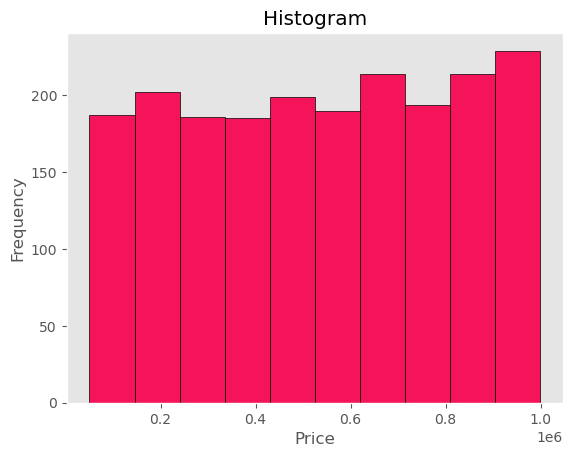

In [26]:
plt.hist(data['Price'],color="#F51359",##Plotting the Histogram
         edgecolor="black")
plt.title("Histogram")
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.grid()
plt.show()

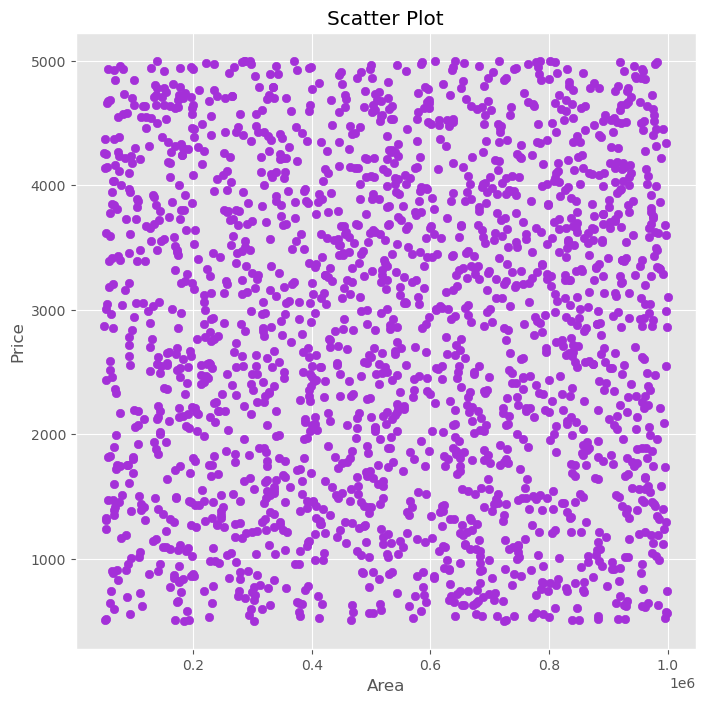

In [28]:
plt.figure(figsize=(8,8))## making a scatter plot which is necessary as it shows how much the data varies 
#here, area is plotted on the x axis as it is an independent variable and price is plotted on the y axis as it is a dependent variable 
#and depends on the area.
plt.scatter(data['Price'],data['Area'],color="#A430D8")
plt.title("Scatter Plot")
plt.xlabel("Area")
plt.ylabel("Price")
plt.show()

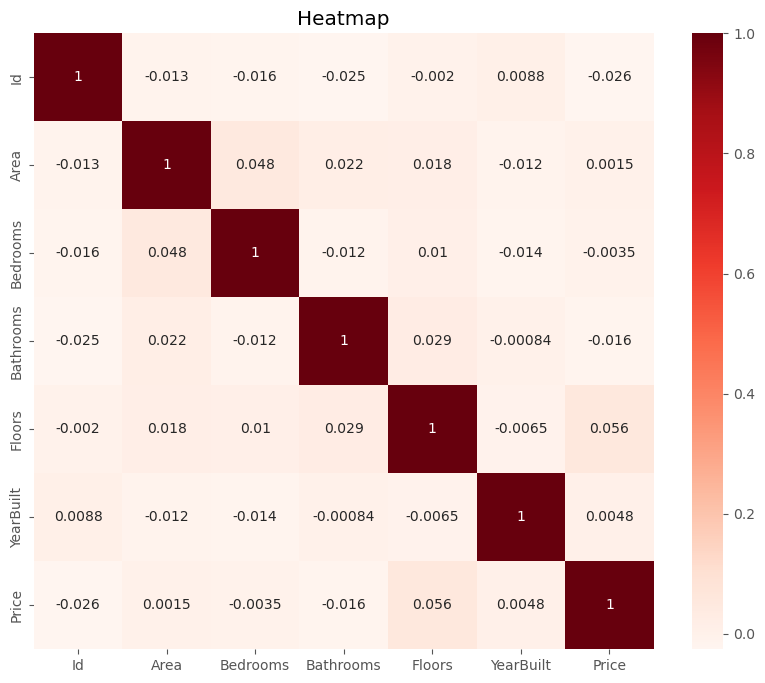

In [30]:
plt.figure(figsize=(10,8))##The figure size is 10,8.
sns.heatmap(data.corr(numeric_only=True),annot=True,cmap='Reds')#data.corr() is basically used for the calculating the correlation coefficients between the numerical variables in the DataFrame.
#annot is used to give the annotation of the correlation coefficients inside each of the boxes shown below.
#The boxes with darker colors have much more stronger correlation than the boxes with lighter colour.
#cmap is used for the colours to the boxes present in the heatmap based on their correlation.
plt.title("Heatmap")
plt.show()

## Step 5 - Converting all the categorical variables into numerical variables 

### Using one hot encoding as we have columns with multiple categories

In [32]:
df = pd.get_dummies(data, columns=["Location", "Condition","Garage"], drop_first=True)# One Hot Encoding converts the feature into different columns and then assign it values based on the dataset

In [35]:
print(df)

        Id  Area  Bedrooms  Bathrooms  Floors  YearBuilt   Price  \
0        1  1360         5          4       3       1970  149919   
1        2  4272         5          4       3       1958  424998   
2        3  3592         2          2       3       1938  266746   
3        4   966         4          2       2       1902  244020   
4        5  4926         1          4       2       1975  636056   
...    ...   ...       ...        ...     ...        ...     ...   
1995  1996  4994         5          4       3       1923  295620   
1996  1997  3046         5          2       1       2019  580929   
1997  1998  1062         5          1       2       1903  476925   
1998  1999  4062         3          1       2       1936  161119   
1999  2000  2989         5          1       3       1903  482525   

      Location_Rural  Location_Suburban  Location_Urban  Condition_Fair  \
0              False              False           False           False   
1              False             

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Id                 2000 non-null   int64
 1   Area               2000 non-null   int64
 2   Bedrooms           2000 non-null   int64
 3   Bathrooms          2000 non-null   int64
 4   Floors             2000 non-null   int64
 5   YearBuilt          2000 non-null   int64
 6   Price              2000 non-null   int64
 7   Location_Rural     2000 non-null   bool 
 8   Location_Suburban  2000 non-null   bool 
 9   Location_Urban     2000 non-null   bool 
 10  Condition_Fair     2000 non-null   bool 
 11  Condition_Good     2000 non-null   bool 
 12  Condition_Poor     2000 non-null   bool 
 13  Garage_Yes         2000 non-null   bool 
dtypes: bool(7), int64(7)
memory usage: 123.2 KB


#### Hence,now no variables are categorical.

## Step 6 - Choosing the features and the target variable

In [36]:
X=df[["Area", "Bedrooms", "Bathrooms", "Floors"]]

In [38]:
print(X)

      Area  Bedrooms  Bathrooms  Floors
0     1360         5          4       3
1     4272         5          4       3
2     3592         2          2       3
3      966         4          2       2
4     4926         1          4       2
...    ...       ...        ...     ...
1995  4994         5          4       3
1996  3046         5          2       1
1997  1062         5          1       2
1998  4062         3          1       2
1999  2989         5          1       3

[2000 rows x 4 columns]


In [40]:
Y=df["Price"]

In [42]:
print(Y)

0       149919
1       424998
2       266746
3       244020
4       636056
         ...  
1995    295620
1996    580929
1997    476925
1998    161119
1999    482525
Name: Price, Length: 2000, dtype: int64


## Step 7 - Split the training and the testing data

In [44]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)##Training data=80% and Testing data=20%

## Step 8 - Import the Linear Regression model

In [46]:
model=LinearRegression()

## Step 9 - Fit the data into the Linear Regression model

In [48]:
model.fit(X_train,Y_train)

LinearRegression()

## Step 10 - Make predictions

In [50]:
prediction=model.predict(X_test)

## Step 11 - Evaluate the model

In [52]:
print(f"\033[1mR2 Score:\033[0m", r2_score(Y_test, prediction))
print(f"\033[1mMean Absolute Error(MAE):\033[0m", mean_absolute_error(Y_test, prediction))
print(f"\033[1mMean Squared Error(MSE):\033[0m",mean_squared_error(Y_test,prediction))
print(f"\033[1mRoot Mean Squared Error(RMSE):\033[0m", np.sqrt(mean_squared_error(Y_test, prediction)))

R2 Score: -0.011607381727367194
Mean Absolute Error(MAE): 244399.69772481022
Mean Squared Error(MSE): 78701869220.47183
Root Mean Squared Error(RMSE): 280538.53428802226


## Step 12 - Save the model as (.pkl) file

In [54]:
with open("house_price_model.pkl", "wb") as file:
    pickle.dump(model, file)
print("Model saved successfully")

Model saved successfully


## Step 13 - Import the GUI(Graphical User Interface) Libraries

In [ ]:
!pip install customtkinter
import customtkinter as ctk

## Step 13 - Load the saved model

In [183]:
with open("house_price_model.pkl", "rb") as file:
    model = pickle.load(file)

## Step 14 - Create the window

In [185]:
ctk.set_appearance_mode("light")
ctk.set_default_color_theme("blue")

app = ctk.CTk()

app.geometry("1100x600")

app.title("House Price Prediction")

''

## Step 15 - Add the title

In [187]:
title = ctk.CTkLabel(
    app,
    text="🏠 House Price Prediction System",
    font=("Poppins",28,"bold"),
    text_color="#6E1E33"
)

title.pack(pady=20)

## Step 16 - Add the buttons

In [189]:
area = ctk.CTkEntry(
    app,
    placeholder_text="Enter the Area:",
    width=300,
    height=45
)

area.pack(pady=10)

In [191]:
bedroom = ctk.CTkEntry(
    app,
    placeholder_text="Enter the number of Bedrooms:",
    width=300,
    height=45
)

bedroom.pack(pady=10)

In [193]:
bathroom = ctk.CTkEntry(
    app,
    placeholder_text="Enter the number of Bathrooms:",
    width=300,
    height=45
)

bathroom.pack(pady=10)

In [195]:
floor = ctk.CTkEntry(
    app,
    placeholder_text="Enter the number of Floors:",
    width=300,
    height=45
)

floor.pack(pady=10)

## Step 17 - Add the prediction function

In [197]:
def predict():

    Area = float(area.get())

    Bedrooms = int(bedroom.get())

    Bathrooms = int(bathroom.get())
    
    Floors = int(floor.get())
    
    data = np.array([[Area,Bedrooms,Bathrooms,Floors]])

    output.configure(text=f"Estimated Price:\n₹{prediction[0]:,.2f}")

    result = model.predict(data)

## Step 18 - Add the prediction button

In [199]:
output = ctk.CTkLabel(
    app,
    text=" ",
    font=("Poppins",22,"bold"),
    text_color="#6E1E33",
    fg_color="#F2C6D0",
    corner_radius=12,
    width=300,
    height=80
)

output.pack(pady=20)

## Step 19 - Add the result label

In [201]:
button = ctk.CTkButton(
    app,
    text="Predict Price",
    command=predict,
    width=220,
    height=50,
    corner_radius=12,
    fg_color="#B23A5B",
    hover_color="#D46A85",
    text_color="#FFFFFF"
)

button.pack(pady=20)

## Step 20 - Run the app

In [1]:
app.mainloop()

NameError: name 'app' is not defined